Different papers analyse what is the best sampling ratio for different tasks. 1:5 to 1:15 is recommended. I will use 1:10.

Also, for scanning new information, newer papers are more relevant, hence in the sampling I will put more emphasis on recent papers.

Here I am looking for a funciton I am happy with to assign weights for the sampling:

# Making the samples

## Choosing a distribution

In [6]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from collections import defaultdict
import random
import matplotlib.pyplot as plt
import os


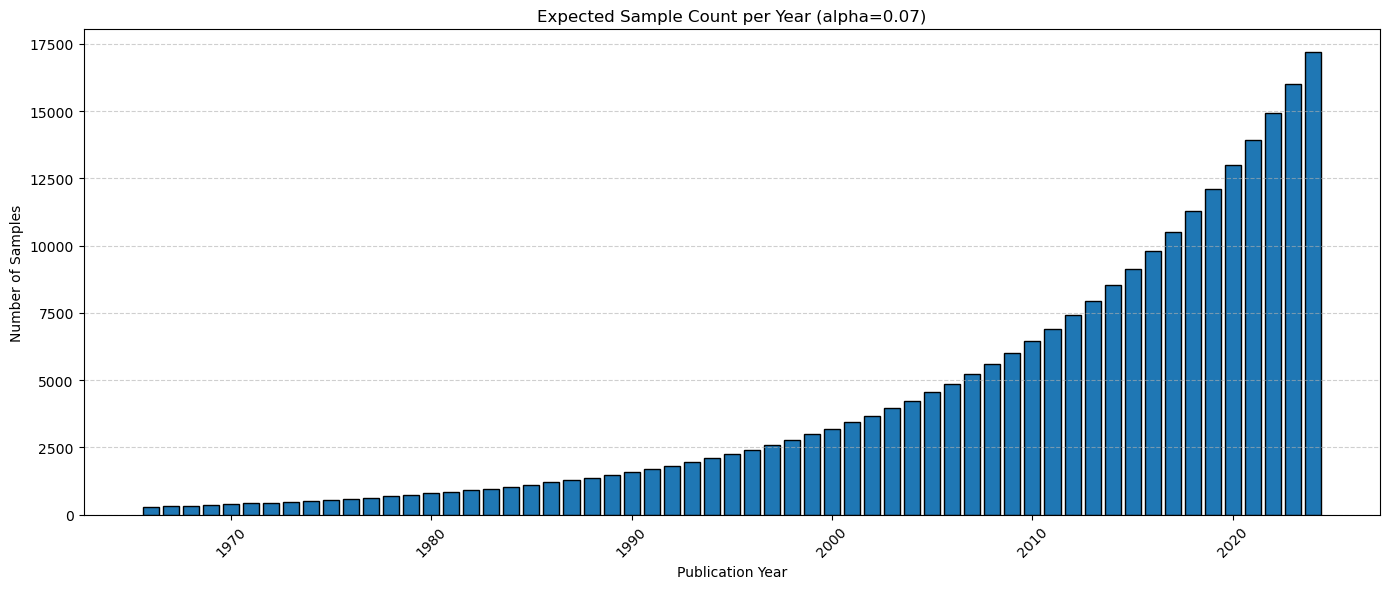

Samples from 2005–2024: 191420 (76.6%)


In [ ]:

# Settings
start_year = 1966
end_year = 2024
target_sample_size = 250_000
alpha = 0.07  # try 0.06 - 0.1 for tuning

# Generate year range and weights
years = np.arange(start_year, end_year + 1)
weights = np.exp(alpha * (years - start_year))
weights /= weights.sum()  # Normalize
expected_samples = (weights * target_sample_size).astype(int)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(years, expected_samples, edgecolor='black')
plt.title(f"Expected Sample Count per Year (alpha={alpha})")
plt.xlabel("Publication Year")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

# Optional: print percentage of samples from 2005+
post_2005_total = expected_samples[years >= 2005].sum()
print(f"Samples from 2005–2024: {post_2005_total} ({post_2005_total / target_sample_size:.1%})")

## 250k with abstracts

In [10]:
# SETTINGS
filename = 'H:/Datasets/pubmed_full.csv'
output_path = 'Samples/pubmed_sample_250k.csv'
chunksize = 1_000_000
target_sample_size = 250_000
start_year, end_year = 1966, 2024
alpha = 0.07
total_rows_estimate = 38_000_000

# Columns to use
df_preview = pd.read_csv(filename, nrows=5)
use_columns = df_preview.columns.tolist()

year_column = 'year'
abstract_column = 'abstract'

# STEP 1: Compute exponential weights
years = np.arange(start_year, end_year + 1)
weights = np.exp(alpha * (years - start_year))
weights /= weights.sum()
expected_counts = (weights * target_sample_size).astype(int)
year_to_sample_count = dict(zip(years, expected_counts))

# STEP 2: Sampling loop
samples = []
total_collected = defaultdict(int)

with pd.read_csv(filename, chunksize=chunksize, usecols=use_columns, dtype={year_column: str}) as reader:
    with tqdm(total=total_rows_estimate, desc="Sampling PubMed", unit="rows") as pbar:
        for chunk in reader:
            pbar.update(len(chunk))

            # Clean and filter
            chunk[year_column] = pd.to_numeric(chunk[year_column], errors='coerce').astype('Int64')
            chunk = chunk.dropna(subset=[year_column, abstract_column])  # Drop rows missing year or abstract

            for year in years:
                year_chunk = chunk[chunk[year_column] == year]
                remaining = year_to_sample_count[year] - total_collected[year]
                if remaining > 0:
                    take_n = min(remaining, len(year_chunk))
                    if take_n > 0:
                        sampled = year_chunk.sample(n=take_n, random_state=42)
                        samples.append(sampled)
                        total_collected[year] += take_n

            if sum(total_collected.values()) >= target_sample_size:
                break

# STEP 3: Combine and Save
sampled_df = pd.concat(samples).reset_index(drop=True)
sampled_df.to_csv(output_path, index=False)

print(f" Sample saved: {output_path}")
print(f" Final sample size: {len(sampled_df)} rows (no null abstracts)")


Sampling PubMed:  13%|█▎        | 5000000/38000000 [01:08<07:06, 77297.74rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\3398523281.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed:  32%|███▏      | 12000000/38000000 [02:52<07:02, 61504.29rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\3398523281.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed:  34%|███▍      | 13000000/38000000 [03:06<06:33, 63496.01rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\3398523281.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed:  96%|█████████▌| 36570000/38000000 [10:25<00:24, 58506.07rows/s]


 Sample saved: Samples/pubmed_sample_250k.csv
 Final sample size: 249971 rows (no null abstracts)


## 400k no abstracts

In [14]:
# SETTINGS
filename = 'H:/Datasets/pubmed_full.csv'
output_path = 'Samples/pubmed_sample_titles_400k.csv'
chunksize = 1_000_000
target_sample_size = 400_000
start_year, end_year = 1966, 2024
alpha = 0.07
total_rows_estimate = 38_000_000

# STEP 1: Read all columns (except we'll drop abstract *after* sampling)
df_preview = pd.read_csv(filename, nrows=5)
use_columns = df_preview.columns.tolist()

year_column = 'year'
abstract_column = 'abstract'

# STEP 2: Compute sampling weights
years = np.arange(start_year, end_year + 1)
weights = np.exp(alpha * (years - start_year))
weights /= weights.sum()
expected_counts = (weights * target_sample_size).astype(int)
year_to_sample_count = dict(zip(years, expected_counts))

# STEP 3: Sample using chunks
samples = []
total_collected = defaultdict(int)

with pd.read_csv(filename, chunksize=chunksize, usecols=use_columns, dtype={year_column: str}) as reader:
    with tqdm(total=total_rows_estimate, desc="Sampling PubMed (Drop Abstract)", unit="rows") as pbar:
        for chunk in reader:
            pbar.update(len(chunk))

            chunk[year_column] = pd.to_numeric(chunk[year_column], errors='coerce').astype('Int64')
            chunk = chunk.dropna(subset=[year_column])  # Keep rows with valid year

            for year in years:
                year_chunk = chunk[chunk[year_column] == year]
                remaining = year_to_sample_count[year] - total_collected[year]
                if remaining > 0:
                    take_n = min(remaining, len(year_chunk))
                    if take_n > 0:
                        sampled = year_chunk.sample(n=take_n, random_state=42)
                        samples.append(sampled)
                        total_collected[year] += take_n

            if sum(total_collected.values()) >= target_sample_size:
                break

# STEP 4: Combine, drop abstract, and save
sampled_df = pd.concat(samples).reset_index(drop=True)

if abstract_column in sampled_df.columns:
    sampled_df.drop(columns=[abstract_column], inplace=True)

sampled_df.to_csv(output_path, index=False)

print(f"Sample saved: {output_path}")
print(f"Final sample size: {len(sampled_df)} rows (excluding abstract column)")

Sampling PubMed (Drop Abstract):  13%|█▎        | 5000000/38000000 [01:06<06:51, 80125.47rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\4269387589.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed (Drop Abstract):  32%|███▏      | 12000000/38000000 [03:01<06:45, 64130.76rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\4269387589.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed (Drop Abstract):  34%|███▍      | 13000000/38000000 [03:03<06:30, 64082.35rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\4269387589.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed (Drop Abstract):  96%|█████████▌| 36570000/38000000 [10:13<00:23, 59645.8

Sample saved: Samples/pubmed_sample_titles_400k.csv
Final sample size: 399972 rows (excluding abstract column)


# Joining the data

## Loading in the datasets

In [18]:
df_ntds = pd.read_csv('Datasets/publicationsDatasetInfoPortals.csv')
df_250k = pd.read_csv('Samples/pubmed_sample_250k.csv')
df_400k = pd.read_csv('Samples/pubmed_sample_titles_400k.csv')

In [24]:
df_ntds_no_nan_abstract = df_ntds[df_ntds['bibcite_abst_e__value'].notna()].copy()
df_ntds_no_nan_abstract.shape

(25435, 29)

In [29]:
df_match_title = pd.read_csv('Aggregates/title_exact_norm_matches_dedup.csv')
print(df_match_title.shape)
print(df_match_title.columns)
df_match_doi = pd.read_csv('Aggregates/doi_matches.csv')
print(df_match_doi.shape)
print(df_match_doi.columns)

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\1856057132.py:1: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_match_title = pd.read_csv('Aggregates/title_exact_norm_matches_dedup.csv')


(30968, 43)
Index(['pmid', 'title_large', 'abstract', 'authors', 'language', 'year',
       'month', 'publication_type', 'country', 'agency', 'mesh_terms', 'doi',
       'norm_title_large', 'Unnamed: 0', 'bib_id', 'bibcite_type', 'uuid',
       'bibcite_title', 'bibcite_year', 'bibcite_secondary_title',
       'bibcite_url', 'bibcite_doi', 'bibcite_abst_e__value',
       'bibcite_abst_f__value', 'bibcite_notes__value',
       'bibcite_custom1__value', 'entity_id', 'field_bibcite_target_id', 'nid',
       'vid', 'type', 'langcode', 'title_small',
       'field_domain_access_target_id', 'Type2', 'Type3', 'Type4', 'Type6',
       'Type7', 'Type8', 'Disease', 'Keywords', 'norm_title_small'],
      dtype='object')
(9911, 41)
Index(['pmid', 'title_large', 'abstract', 'authors', 'language', 'year',
       'month', 'publication_type', 'country', 'agency', 'mesh_terms', 'doi',
       'Unnamed: 0', 'bib_id', 'bibcite_type', 'uuid', 'bibcite_title',
       'bibcite_year', 'bibcite_secondary_title

## Removing the papers that are in the infoNTD form the samples
To avoid duped data

In [31]:
# Step 1: Get matched PMIDs
pmids_title_matches = set(df_match_title['pmid'].dropna().astype(str))
pmids_doi_matches = set(df_match_doi['pmid'].dropna().astype(str))

# Step 2: Combine into one exclusion set
pmids_to_remove = pmids_title_matches.union(pmids_doi_matches)

# Step 3: Clean df_250k
print(f"📦 250k sample before cleaning: {df_250k.shape}")
df_250k['pmid'] = df_250k['pmid'].astype(str)
df_250k_clean = df_250k[~df_250k['pmid'].isin(pmids_to_remove)]
removed_250k = len(df_250k) - len(df_250k_clean)
print(f"✅ 250k sample after cleaning: {df_250k_clean.shape} ({removed_250k} removed)")

# Step 4: Clean df_400k
print(f"\n📦 400k sample before cleaning: {df_400k.shape}")
df_400k['pmid'] = df_400k['pmid'].astype(str)
df_400k_clean = df_400k[~df_400k['pmid'].isin(pmids_to_remove)]
removed_400k = len(df_400k) - len(df_400k_clean)
print(f"✅ 400k sample after cleaning: {df_400k_clean.shape} ({removed_400k} removed)")


📦 250k sample before cleaning: (249971, 12)
✅ 250k sample after cleaning: (249869, 12) (102 removed)

📦 400k sample before cleaning: (399972, 11)
✅ 400k sample after cleaning: (399759, 11) (213 removed)


## Joining and making target

In [38]:
# Step 1: Clean and tag NTDs
df_ntds_all = df_ntds.copy()
df_ntds_all['target'] = 1  # Mark as positive class

# Subset for 250k (abstracts only)
df_ntds_with_abstract = df_ntds_all[df_ntds_all['bibcite_abst_e__value'].notna()].copy()

# Step 2: Rename NTD columns to match sample structure for key fields
def rename_ntds_columns(df):
    return df.rename(columns={
        'bibcite_year': 'year',
        'bibcite_doi': 'doi',
        'bibcite_abst_e__value': 'abstract'
    })

df_ntds_250k = rename_ntds_columns(df_ntds_with_abstract)
df_ntds_400k = rename_ntds_columns(df_ntds_all)

# Step 3: Label sample datasets
df_250k_clean['target'] = 0
df_400k_clean['target'] = 0

# Step 4: Combine — outer concat to include all columns from both sides
df_combined_250k = pd.concat([df_250k_clean, df_ntds_250k], ignore_index=True, sort=False)
df_combined_400k = pd.concat([df_400k_clean, df_ntds_400k], ignore_index=True, sort=False)

# Step 5: Report
print(f"📦 Combined 250k shape: {df_combined_250k.shape}")
print(f"✅ 250k — Target=1: {df_combined_250k['target'].sum()}, Target=0: {(df_combined_250k['target'] == 0).sum()}")

print(f"\n📦 Combined 400k shape: {df_combined_400k.shape}")
print(f"✅ 400k — Target=1: {df_combined_400k['target'].sum()}, Target=0: {(df_combined_400k['target'] == 0).sum()}")


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\70867647.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_250k_clean['target'] = 0
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\70867647.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_400k_clean['target'] = 0


📦 Combined 250k shape: (275304, 38)
✅ 250k — Target=1: 25435, Target=0: 249869

📦 Combined 400k shape: (442122, 38)
✅ 400k — Target=1: 42363, Target=0: 399759


In [40]:
# Add a unique integer ID to each row
df_combined_250k['row_id'] = np.arange(len(df_combined_250k))
df_combined_400k['row_id'] = np.arange(len(df_combined_400k))

#  make sure it's the first column
cols_250k = ['row_id'] + [col for col in df_combined_250k.columns if col != 'row_id']
cols_400k = ['row_id'] + [col for col in df_combined_400k.columns if col != 'row_id']

df_combined_250k = df_combined_250k[cols_250k]
df_combined_400k = df_combined_400k[cols_400k]


## Adjusting target according to MESH terms

In [43]:
def flag_mesh_terms(df, mesh_column='mesh_terms', target_column='target', base_target_column='target_no_mesh_adjustment', ntd_terms=None):
    """
    Creates a new 'target' column based on mesh term matching, preserving the original target.
    """
    if ntd_terms is None:
        ntd_terms = []

    ntd_set = {term.strip().lower() for term in ntd_terms}

    # Copy original target
    df = df.copy()
    df[base_target_column] = df[target_column]

    # Update target with mesh term flags
    def update_target(row):
        if row[base_target_column] == 1:
            return 1
        mesh_str = row.get(mesh_column, "")
        if pd.isna(mesh_str):
            return 0
        mesh_list = [m.strip().lower() for m in mesh_str.split(';')]
        return int(any(term in ntd_set for term in mesh_list))

    df[target_column] = df.apply(update_target, axis=1)
    return df


In [61]:
# Define NTD-related MeSH terms
ntd_mesh_terms = [
    "Schistosomiasis",
    "Lymphatic Filariasis",
    "Elephantiasis",
    "Leprosy",
    "Leprosy, Tuberculoid",
    "Leprosy, Lepromatous",
    "Leprosy, Borderline",
    "Leprosy, Paucibacillary",
    "Leprosy, Multibacillary",
    "Soil-Transmitted Helminth Infections",
    "Ascaris lumbricoides",
    "Trichuris trichiura",
    "Hookworm Infections",
    "Leishmaniasis",
    "Leishmaniasis, Cutaneous",
    "Leishmaniasis, Visceral",
    "Onchocerciasis",
    "Trachoma",
    "Chagas Disease",
    "American Trypanosomiasis",
    "Buruli Ulcer",
    "Snake Bites",
    "Snake Venoms",
    "Trypanosomiasis, African",
    "Sleeping Sickness",
    "Yaws",
    "Mycetoma",
    "Eumycetoma",
    "Actinomycetoma",
    "Podoconiosis",
    "Dracunculiasis",
    "Guinea Worm Disease",
    "Scabies",
    "Zika Virus Infection",
    "Chromoblastomycosis",
    "Noma"
]

# Apply to both datasets
df_combined_250k_adjusted = flag_mesh_terms(df_combined_250k, ntd_terms=ntd_mesh_terms)
df_combined_400k_adjusted = flag_mesh_terms(df_combined_400k, ntd_terms=ntd_mesh_terms)

# Show change counts
added_250k = (df_combined_250k_adjusted['target'] == 1).sum() - (df_combined_250k_adjusted['target_no_mesh_adjustment'] == 1).sum()
added_400k = (df_combined_400k_adjusted['target'] == 1).sum() - (df_combined_400k_adjusted['target_no_mesh_adjustment'] == 1).sum()

print(f"🆕 250k: {added_250k} rows flagged by mesh_terms")
print(f"🆕 400k: {added_400k} rows flagged by mesh_terms")


🆕 250k: 473 rows flagged by mesh_terms
🆕 400k: 790 rows flagged by mesh_terms


## Making the split

In [62]:
from sklearn.model_selection import train_test_split
import os

In [63]:
# Helper to split and save
def split_and_save(df, name, label_col='target', test_size=0.2, seed=42):
    df_train, df_test = train_test_split(
        df,
        stratify=df[label_col],
        test_size=test_size,
        random_state=seed
    )

    df_train = df_train.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    train_path = f"Datasets/Train/{name}_train.csv"
    test_path = f"Datasets/Test/{name}_test.csv"

    df_train.to_csv(train_path, index=False)
    df_test.to_csv(test_path, index=False)

    print(f"✅ {name} split:")
    print(f"   Train → {train_path} ({df_train.shape[0]} rows, positives: {df_train[label_col].sum()})")
    print(f"   Test  → {test_path}  ({df_test.shape[0]} rows, positives: {df_test[label_col].sum()})")

# Run for both datasets
split_and_save(df_combined_250k_adjusted, name="250k")
split_and_save(df_combined_400k_adjusted, name="400k_titles")

✅ 250k split:
   Train → Datasets/Train/250k_train.csv (220243 rows, positives: 20726)
   Test  → Datasets/Test/250k_test.csv  (55061 rows, positives: 5182)
✅ 400k_titles split:
   Train → Datasets/Train/400k_titles_train.csv (353697 rows, positives: 34522)
   Test  → Datasets/Test/400k_titles_test.csv  (88425 rows, positives: 8631)


In [65]:
# --- 1. Exclude infontd_org → name: infolep
df_250k_infolep = df_combined_250k_adjusted[df_combined_250k_adjusted['field_domain_access_target_id'] != 'infontd_org'].copy()
df_400k_infolep = df_combined_400k_adjusted[df_combined_400k_adjusted['field_domain_access_target_id'] != 'infontd_org'].copy()

split_and_save(df_250k_infolep, name="250k_infolep")
split_and_save(df_400k_infolep, name="400k_titles_infolep")

# --- 2. Exclude leprosy_information_org → name: infontd
df_250k_infontd = df_combined_250k_adjusted[df_combined_250k_adjusted['field_domain_access_target_id'] != 'leprosy_information_org'].copy()
df_400k_infontd = df_combined_400k_adjusted[df_combined_400k_adjusted['field_domain_access_target_id'] != 'leprosy_information_org'].copy()

split_and_save(df_250k_infontd, name="250k_infontd")
split_and_save(df_400k_infontd, name="400k_titles_infontd")

✅ 250k_infolep split:
   Train → Datasets/Train/250k_infolep_train.csv (214426 rows, positives: 14910)
   Test  → Datasets/Test/250k_infolep_test.csv  (53607 rows, positives: 3727)
✅ 400k_titles_infolep split:
   Train → Datasets/Train/400k_titles_infolep_train.csv (346646 rows, positives: 27471)
   Test  → Datasets/Test/400k_titles_infolep_test.csv  (86662 rows, positives: 6868)
✅ 250k_infontd split:
   Train → Datasets/Train/250k_infontd_train.csv (205712 rows, positives: 6195)
   Test  → Datasets/Test/250k_infontd_test.csv  (51428 rows, positives: 1549)
✅ 400k_titles_infontd split:
   Train → Datasets/Train/400k_titles_infontd_train.csv (326858 rows, positives: 7683)
   Test  → Datasets/Test/400k_titles_infontd_test.csv  (81715 rows, positives: 1921)
